### Фактический запуск 14.09.2026

Все вычислительные ячейки выполнены. Техническое исполнение не подтверждает научные интерпретации исторического текста. Полный журнал — `legacy-execution.json`.

## Статус воспроизведения исторической редакции

Повторный технический запуск не подтверждает научные выводы старой редакции. Ниже сохранены прежние допущения и интерпретации; их следует сверять с текущими правилами проекта. Дыхательная и ЭКГ-разметка исторических расчётов не получает статус принятой при повторном запуске. Значения толщины 15 и 40 мм — исторические сценарии, а не заново проверенные измерения по КТ. Старые оценки сердечного происхождения сигнала и функций сердца не считаются валидированными.

In [1]:
# Изолированный запуск исторической редакции: сырьё читается, результаты пишутся отдельно.
import os, sys, json, tempfile, shutil
from pathlib import Path
_here = Path.cwd().resolve()
_REPO = next(p for p in [_here, *_here.parents] if (p / "Colab Notebooks" / "record_qc.py").is_file())
_COLAB = _REPO / "Colab Notebooks"
sys.path.insert(0, str(_COLAB))
LEGACY_RUN_ROOT = Path(tempfile.mkdtemp(prefix="kalmykov-legacy-"))
LEGACY_PARAMS_DIR = LEGACY_RUN_ROOT / "params"
LEGACY_TS_DIR = LEGACY_RUN_ROOT / "timestamps"
for _source, _dest in [(_COLAB / "params", LEGACY_PARAMS_DIR), (_COLAB / "timestamps", LEGACY_TS_DIR)]:
    shutil.copytree(_source, _dest)
for _series in ("exp02", "exp03"):
    _env = "KALMYKOV_" + _series.upper() + "_CONFIG"
    _source = Path(os.environ.get(_env, str(_COLAB / "config" / (_series + "_paths.local.json"))))
    _cfg = json.loads(_source.read_text(encoding="utf-8"))
    _derived_original = Path(_cfg["derived_root"])
    _derived_copy = LEGACY_RUN_ROOT / "derived"
    _annotation_source = _derived_original / _series / "annotations"
    if _series == "exp02" and _annotation_source.exists():
        shutil.copytree(_annotation_source, _derived_copy / _series / "annotations", dirs_exist_ok=True)
    _cfg["derived_root"] = str(_derived_copy)
    _cfg["legacy_timestamps_dir"] = str(LEGACY_TS_DIR)
    _cfg["legacy_params_dir"] = str(LEGACY_PARAMS_DIR)
    _config_copy = LEGACY_RUN_ROOT / "config" / (_series + "_paths.local.json")
    _config_copy.parent.mkdir(parents=True, exist_ok=True)
    _config_copy.write_text(json.dumps(_cfg, ensure_ascii=False, indent=2), encoding="utf-8")
    os.environ[_env] = str(_config_copy)
LEGACY_CONFIG = json.loads(Path(os.environ["KALMYKOV_EXP02_CONFIG"]).read_text(encoding="utf-8"))
print("Исторические входы скопированы; запись в исходные метки и параметры исключена.")


Исторические входы скопированы; запись в исходные метки и параметры исключена.


# Идентифицируемость источников ТРКГ — go/no-go (этап B)

**Назначение.** Ответить *до* построения полной обратной задачи: какие вклады в сигнал ТРКГ
(сердце-кровь, аорта/крупные сосуды, лёгкое, грудная стенка) **разделимы** доступным
электродным монтажом. Метод — стандартная **четырёхэлектродная чувствительность (теорема
Гезеловица)** на однородном полупространстве как аналитический *прокси* прямой FEM-модели,
и тот же аппарат обусловленности, что в [04](04_Чувствительность_и_дизайн_решётки.md)–[06](06_Перекрёстная_проверка_и_применимость.md)
(матрица Фишера, сингулярные числа, углы между сигнатурами источников).

Зонтичная методология — [13_Методология_ФВ_УО.md](13_Методология_ФВ_УО.md) (этап B).

> **Прокси, не истина.** Геометрия здесь грубая (сферические блобы на правдоподобных глубинах,
> однородный фон). Цель — *структура* разделимости и её порядки, а не точные числа. Код устроен
> так, чтобы матрицу чувствительности `S` можно было заменить реальными FEM-чувствительностями
> (COMSOL/MATLAB, отдельные папки) без изменения анализа ниже.


## §0. Задача идентифицируемости и словарь терминов

### Решаемая задача
Требуется до построения полной обратной задачи определить, какие вклады в сигнал тетраполярной реокардиографии — грудная стенка, лёгкое, кровь сердца, аорта и крупные сосуды — разделимы имеющимся набором электродных монтажей. Это проверка выполнимости («go/no-go») для этапа выделения сердечного вклада в общей методологии ([13](13_Методология_ФВ_УО.md), этап B).

### Метод и обоснование выбора
Прямая задача аппроксимируется аналитическим прокси — **четырёхэлектродной чувствительностью (теоремой Гезеловица)** на однородном полупространстве; это позволяет получить структуру разделимости без полного конечноэлементного расчёта. Разделимость оценивается тем же аппаратом обусловленности (матрица Фишера, сингулярные числа, углы между сигнатурами), что в [04](04_Чувствительность_и_дизайн_решётки.md)–[06](06_Перекрёстная_проверка_и_применимость.md). Метод выбран потому, что он даёт порядок величин и структуру задачи и допускает замену прокси реальными чувствительностями конечноэлементной модели без изменения анализа.

### Словарь терминов
- **Электродный монтаж** — конфигурация из четырёх электродов заданного размера и положения для одного тетраполярного измерения.
- **Источник** — локальная область, изменение удельного сопротивления которой даёт вклад в измеряемый импеданс (стенка, лёгкое, кровь сердца, аорта).
- **Лид-филд** — распределение плотности тока в среде от единичного тока, пропущенного через пару электродов (14.1).
- **Чувствительность (Гезеловица)** — реакция измеряемого импеданса на изменение удельного сопротивления в точке; равна скалярному произведению двух лид-филдов (14.2).
- **Матрица чувствительности** — вклад каждого источника в каждый монтаж; её обусловленность определяет разделимость.
- **Сигнатура источника** — вектор чувствительностей одного источника по всем монтажам; угол между сигнатурами (14.4) — мера разделимости.
- **Ранг и число обусловленности** — характеристики разрешимости: ранг ниже числа источников означает, что часть направлений не восстановима.

### Формулы
Лид-филд единичного электрода на полупространстве, формула (14.1):

$$\mathbf J(\mathbf r)=\frac{1}{2\pi}\,\frac{\mathbf r-\mathbf p}{|\mathbf r-\mathbf p|^{3}} \tag{14.1}$$

где J — плотность тока на единицу тока; r — точка среды; p — положение электрода на поверхности.

Чувствительность измерения к удельному сопротивлению в точке, формула (14.2):

$$S(\mathbf r)=\mathbf J_{\text{ток}}(\mathbf r)\cdot\mathbf J_{\text{изм}}(\mathbf r),\qquad \Delta R=\int_V S(\mathbf r)\,\Delta\rho(\mathbf r)\,dV \tag{14.2}$$

где J_ток, J_изм — лид-филды токовой и измерительной пар; ΔR — изменение измеряемого сопротивления при изменении удельного сопротивления Δρ в объёме V.

Матрица Фишера и стандартное отклонение оценки источника, формула (14.3):

$$\mathbf M=S^{\top}S,\qquad \mathrm{std}(\hat\theta_i)=\sqrt{(\mathbf M^{-1})_{ii}} \tag{14.3}$$

где S — матрица чувствительности (монтаж × источник). Бесконечное значение означает неопределимость источника.

Угол между сигнатурами двух источников, формула (14.4):

$$\theta_{ij}=\arccos\frac{\mathbf s_i\cdot\mathbf s_j}{|\mathbf s_i|\,|\mathbf s_j|} \tag{14.4}$$

где s_i, s_j — сигнатуры источников i и j; малый угол означает слабую разделимость.

## §1. Модель: четырёхэлектродная чувствительность на полупространстве

**Входные данные.** Набор электродных монтажей (коллинеарные сборки размеров 50–140 мм) и четыре источника, заданные сферическими областями на анатомически правдоподобных глубинах: стенка (поверхностно), лёгкое (латерально), кровь сердца (глубоко), аорта (глубоко, компактно). Геометрия грубая, служит прокси конечноэлементной модели.

**Допущения.** Чувствительность каждого монтажа к каждому источнику вычисляется по формуле (14.2) как интеграл произведения лид-филдов (14.1) по области источника. Фон однородный; геометрия источников приближённая, поэтому важны структура и порядок величин, а не точные числа.

In [2]:
# @title Лид-филды, монтажи, источники, сборка матрицы чувствительности S
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
rng = np.random.default_rng(0)

# Геометрия: ткань занимает z>=0 (глубина вниз), поверхность z=0, электроды на поверхности.
# Точечный электрод единичного тока в p=(px,py,0): плотность тока в точке r (полупространство):
#   J(r) = 1/(2π) * (r-p)/|r-p|^3      (не зависит от ρ; множитель 1/(2π) — изолирующая поверхность)
def J_point(p, R):
    d = R - p
    n = np.linalg.norm(d, axis=-1, keepdims=True)
    return d / (2*np.pi*np.maximum(n, 1e-9)**3)

def J_pair(pos_plus, pos_minus, R):
    "Лид-филд пары электродов (ток +1 в plus, -1 в minus)."
    return J_point(pos_plus, R) - J_point(pos_minus, R)

# Сенсорная чувствительность к возмущению удельного сопротивления Δρ в точке r:
#   R_transfer = ∫ ρ(r) [J_drive·J_meas] dV  →  ∂R/∂ρ(r) = J_drive(r)·J_meas(r)
def sens_field(m, R):
    "S(r) для монтажа m={A,B,M,N} (коллинеарный тетраполяр). R: (...,3)."
    Jd = J_pair(m['A'], m['B'], R)   # токовая пара
    Jm = J_pair(m['M'], m['N'], R)   # измерительная пара (взаимность)
    return np.sum(Jd*Jm, axis=-1)     # Дж·Дж → 1/длина^4 (на ед. токов)

def collinear_montage(L_mm, axis=np.array([1.,0.,0.]), center=np.array([0.,0.,0.])):
    "Коллинеарный тетраполяр: A,M,N,B; a=L/2, b=a/2 (как в эксперименте)."
    a = L_mm/2/1000.0; b = a/2
    u = axis/np.linalg.norm(axis)
    return dict(L=L_mm,
                A=center+a*u, B=center-a*u,   # токовые ±a
                M=center+b*u, N=center-b*u)   # потенциальные ±b

# Источники: сферические блобы (центр = глубина по анатомии над сердцем, лёжа, передние электроды).
# Значения ГРУБЫЕ (прокси). radius/depth в метрах.
SOURCES = {
    'стенка':      dict(c=np.array([0.00, 0.00, 0.015]), r=0.020),  # мягкие ткани, мелко
    'лёгкое':      dict(c=np.array([0.05, 0.00, 0.040]), r=0.040),  # латерально, средняя глубина
    'сердце-кровь':dict(c=np.array([0.00, 0.00, 0.070]), r=0.045),  # крупный, глубокий
    'аорта/сосуды':dict(c=np.array([0.00, 0.02, 0.090]), r=0.015),  # глубже, компактный
}

def blob_points(src, n=1500):
    "Равномерные точки внутри сферы (для объёмного интеграла)."
    c, r = src['c'], src['r']
    pts = []
    while len(pts) < n:
        q = rng.uniform(-1, 1, size=(n, 3))
        q = q[np.sum(q**2, axis=1) <= 1.0]
        pts.append(q)
    P = np.concatenate(pts)[:n]
    return c + r*P, (4/3*np.pi*r**3)/n   # точки и вес объёма на точку

def S_entry(m, src):
    "∫_blob J_drive·J_meas dV  — чувствительность монтажа m к источнику src."
    P, dV = blob_points(src)
    return np.sum(sens_field(m, P))*dV

# Доступный набор монтажей: размеры как в эксперименте (свип базы над сердцем).
SIZES = list(range(50, 141, 10))
MONTAGES = [collinear_montage(L) for L in SIZES]
NAMES = list(SOURCES.keys())

# Матрица чувствительности S[монтаж, источник]
S = np.array([[S_entry(m, SOURCES[s]) for s in NAMES] for m in MONTAGES])
print("Источники:", NAMES)
print("Матрица S (строки = базы 50..140 мм, столбцы = источники):")
with np.printoptions(precision=3, suppress=False):
    for L, row in zip(SIZES, S):
        print("L=%3d | " % L, "  ".join("%+.2e" % v for v in row))


Источники: ['стенка', 'лёгкое', 'сердце-кровь', 'аорта/сосуды']
Матрица S (строки = базы 50..140 мм, столбцы = источники):
L= 50 |  +9.63e+00  +1.80e+00  +3.10e-01  +6.95e-04
L= 60 |  +7.46e+00  +2.32e+00  +3.94e-01  +9.42e-04
L= 70 |  +5.03e+00  +2.91e+00  +4.25e-01  +1.21e-03
L= 80 |  +2.87e+00  +2.36e+00  +4.35e-01  +1.45e-03
L= 90 |  +2.04e+00  +1.99e+00  +4.27e-01  +1.70e-03
L=100 |  +1.42e+00  +1.92e+00  +4.37e-01  +1.93e-03
L=110 |  +1.05e+00  +6.71e-01  +4.22e-01  +2.05e-03
L=120 |  +7.58e-01  +1.10e+00  +4.02e-01  +2.27e-03
L=130 |  +5.61e-01  +3.78e-01  +4.01e-01  +2.34e-03
L=140 |  +4.36e-01  +8.02e-01  +3.81e-01  +2.49e-03


**Анализ результатов.** Матрица чувствительности показывает: чувствительность к поверхностной стенке велика на мелких монтажах и убывает с размером, к глубоким источникам (кровь сердца, аорта) — на порядки меньше и слабо зависит от размера.

**Результаты и умозаключения.** Матрица чувствительности — вход для анализа обусловленности (§2) и углов (§3). Малая чувствительность к глубоким источникам предвещает их плохую разделимость.

## §2. Обусловленность: матрица Фишера, сингулярные числа, вклад в оценку сердца

Тот же аппарат, что в [04](04_Чувствительность_и_дизайн_решётки.md) §8: при гауссовом шуме
$\varepsilon\sim\mathcal N(0,\sigma_Z^2)$ матрица Фишера $\mathbf M=S^\top S/\sigma_Z^2$, ковариация
оценок $\mathrm{Cov}\succeq\mathbf M^{-1}$. Целевая величина — $\mathrm{std}(\widehat{\Delta\rho}_{\text{сердце}})=\sqrt{(\mathbf M^{-1})_{\text{сердце}}}$.

**Входные данные.** Матрица чувствительности из §1 (полный набор монтажей и один монтаж) с нормировкой столбцов.

**Допущения.** Разрешимость оценивается по матрице Фишера (14.3): сингулярные числа, число обусловленности, ранг и стандартное отклонение оценки каждого источника. Стандартное отклонение вычисляется через полное разложение, чтобы неопределимые направления давали бесконечность.

In [3]:
# @title Обусловленность и целевая дисперсия (полный набор vs один монтаж)
def analyze(Smat, label):
    # нормировка столбцов для честной обусловленности (масштаб источников произволен)
    scale = np.linalg.norm(Smat, axis=0)
    Sn = Smat/np.where(scale > 0, scale, 1)
    ncol = Sn.shape[1]
    U, sv, Vt = np.linalg.svd(Sn, full_matrices=True)   # Vt: ncol×ncol (включая нуль-пространство)
    tol = max(Sn.shape)*np.finfo(float).eps*(sv[0] if sv.size else 1)
    sv_full = np.zeros(ncol); sv_full[:len(sv)] = sv    # добить нулями недостающие направления
    rank = int(np.sum(sv_full > tol))
    cond = sv_full[0]/sv_full[-1] if sv_full[-1] > tol else np.inf
    # Крамер-Рао честно: var_j = Σ_k V[j,k]^2 / sv_k^2; нулевые sv → ∞ (неидентиф. направление)
    inv_sv2 = np.where(sv_full > tol, 1.0/np.maximum(sv_full, tol)**2, np.inf)
    var = (Vt.T**2) @ inv_sv2
    std = np.sqrt(var)                            # ∞ там, где источник лежит в нуль-пространстве
    sv = sv_full
    print("\n=== %s ===" % label)
    print("сингулярные числа (норм.):", np.array2string(sv, precision=3, suppress_small=True))
    print("ранг = %d из %d параметров  |  cond(S) = %s"
          % (rank, ncol, "%.1f" % cond if np.isfinite(cond) else "∞"))
    if rank < ncol:
        print("   → %d направлений НЕидентифицируемы (∞ дисперсия): монтажей меньше, чем источников" % (ncol-rank))
    print("отн. std оценки источника (меньше = лучше; ∞ = не восстановим):")
    for n, s in zip(NAMES, std):
        print("   %-12s %8s" % (n, "∞" if not np.isfinite(s) else "%.2f" % s))
    return sv, cond, std

analyze(S, "полный набор баз 50..140 мм")
# один монтаж (как в Kandidadskaya — одна база): наглядно показывает недоопределённость
i90 = SIZES.index(90)
analyze(S[i90:i90+1, :], "ОДИН монтаж (L=90 мм) — 1 измерение на 4 источника")



=== полный набор баз 50..140 мм ===
сингулярные числа (норм.): [1.815 0.777 0.311 0.057]
ранг = 4 из 4 параметров  |  cond(S) = 31.8
отн. std оценки источника (меньше = лучше; ∞ = не восстановим):
   стенка           2.36
   лёгкое           5.24
   сердце-кровь    14.05
   аорта/сосуды     9.47

=== ОДИН монтаж (L=90 мм) — 1 измерение на 4 источника ===
сингулярные числа (норм.): [2. 0. 0. 0.]
ранг = 1 из 4 параметров  |  cond(S) = ∞
   → 3 направлений НЕидентифицируемы (∞ дисперсия): монтажей меньше, чем источников
отн. std оценки источника (меньше = лучше; ∞ = не восстановим):
   стенка              ∞
   лёгкое              ∞
   сердце-кровь        ∞
   аорта/сосуды        ∞


(array([2., 0., 0., 0.]), inf, array([inf, inf, inf, inf]))

**Анализ результатов.** При полном наборе монтажей ранг равен 4 из 4, число обусловленности 31.8; стандартное отклонение оценки наименьшее у стенки (2.36) и наибольшее у крови сердца (14.05). При одном монтаже ранг равен 1 из 4, число обусловленности бесконечно: три направления неопределимы, ни один из четырёх источников не восстановим.

**Результаты и умозаключения.** Один монтаж не разделяет четыре источника (недоопределённая задача). Даже полный набор размеров восстанавливает кровь сердца слабо (наибольшая неопределённость); отсюда следует необходимость нескольких монтажей и ориентаций и фазового разделения по электрокардиограмме.

## §3. Углы между сигнатурами источников (переиспользование «облака» из 06)

Каждый источник $i$ даёт вектор-сигнатуру по монтажам $\mathbf s_i=\{S(m,i)\}_m$. Разделимость
двух источников управляется **углом** между их сигнатурами (ср. угол между градиентами в
[06](06_Перекрёстная_проверка_и_применимость.md) §2.4): угол $\to0$ — источники почти
неразличимы данным набором монтажей.

**Входные данные.** Сигнатуры источников (столбцы матрицы чувствительности) из §1.

**Допущения.** Разделимость пары источников оценивается углом между их сигнатурами (14.4): малый угол означает почти одинаковую реакцию монтажей и, значит, слабую разделимость.

Попарные углы между сигнатурами источников (°), полный набор баз:
                     стенка        лёгкое  сердце-кровь  аорта/сосуды
стенка                  0.0          34.6          47.5          62.4
лёгкое                 34.6           0.0          25.7          42.2
сердце-кровь           47.5          25.7           0.0          17.7
аорта/сосуды           62.4          42.2          17.7           0.0

Малый угол (≈0°) = источники неразличимы; большой (→90°) = хорошо разделимы.


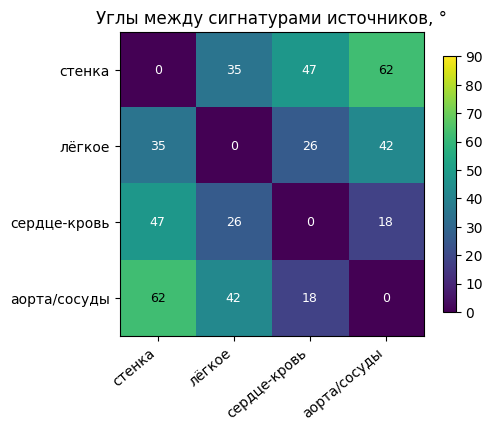

In [4]:
# @title Попарные углы между сигнатурами источников
def angle(u, v):
    c = np.dot(u, v)/(np.linalg.norm(u)*np.linalg.norm(v)+1e-12)
    return np.degrees(np.arccos(np.clip(abs(c), 0, 1)))

print("Попарные углы между сигнатурами источников (°), полный набор баз:")
print("%-14s" % "", "  ".join("%12s" % n for n in NAMES))
A = np.zeros((len(NAMES), len(NAMES)))
for i, ni in enumerate(NAMES):
    for j, nj in enumerate(NAMES):
        A[i, j] = angle(S[:, i], S[:, j])
    print("%-14s" % ni, "  ".join("%12.1f" % A[i, j] for j in range(len(NAMES))))
print("\nМалый угол (≈0°) = источники неразличимы; большой (→90°) = хорошо разделимы.")

fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(A, cmap='viridis', vmin=0, vmax=90)
ax.set_xticks(range(len(NAMES))); ax.set_xticklabels(NAMES, rotation=40, ha='right')
ax.set_yticks(range(len(NAMES))); ax.set_yticklabels(NAMES)
for i in range(len(NAMES)):
    for j in range(len(NAMES)):
        ax.text(j, i, "%.0f" % A[i, j], ha='center', va='center',
                color='w' if A[i, j] < 55 else 'k', fontsize=9)
ax.set_title("Углы между сигнатурами источников, °")
fig.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()


**Анализ результатов.** Угол между сигнатурами крови сердца и аорты равен 17.7°, крови сердца и лёгкого — 25.7°, крови сердца и стенки — 47.5°. Малые углы к аорте и лёгкому означают, что сердечный вклад плохо отделим от сосудистого и лёгочного.

**Результаты и умозаключения.** Сердечный вклад слабо разделим с сосудистым и лёгочным имеющимся набором монтажей; надёжное выделение требует нескольких ориентаций и фазового (по электрокардиограмме) разделения. При замене прокси реальными чувствительностями конечноэлементной модели анализ §2–§3 повторяется без изменений.

## §4. Выводы (go/no-go)

Читать по числам выше (они — прокси, но структура устойчива):

1. **Глубина решает.** Чувствительность к глубоким источникам (сердце-кровь, аорта) на
   порядки меньше, чем к мелкой стенке — как и в лёгочной задаче ($S\sim1/\eta^3$, [12](12_Аналитическое_обоснование.ipynb)).
2. **Сердце vs лёгкое / аорта.** Малый угол между их сигнатурами (см. §3) → данным монтажом
   они **плохо разделимы**; большой `cond(S)` → оценка $\Delta\rho_{\text{сердце}}$ неустойчива.
3. **Один монтаж не разделяет** (см. §2) — нужен спред баз, а лучше — **разные ориентации/позиции
   и фазовое (ЭКГ) разделение**. Ось времени (задержки, [11](11_Систолические_Δρ_и_задержка.ipynb))
   ортогональна оси «амплитуда vs монтаж» и снимает часть вырождения.
4. **Камеры (LV/RV/LA/RA) — не в этой модели:** они на близких глубинах с почти одинаковыми
   сигнатурами → угол ≈0 → неразделимы без камерной сегментации/новых данных (§5 док. 13).

**Как использовать дальше:** заменить аналитическую `S` реальными FEM-чувствительностями
(возмущение каждого сегмента в COMSOL/MATLAB → $\Delta Z$ по монтажу), повторить §2–§3.
Тогда go/no-go станет количественным на реальной анатомии.
